# Train Linear Regression Model

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from time import time

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    average_precision_score, matthews_corrcoef, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

# Loading dataset

In [5]:
data_path = Path("/Users/eugene_kuj/PycharmProjects/DS_lab/data/merged_preprocessed.csv")

df = pd.read_csv(data_path)

df.head()


,region_id,time,alarm,hour_temp,hour_feelslike,hour_humidity,hour_dew,hour_precip,hour_precipprob,hour_preciptype,hour_windspeed,hour_winddir,hour_pressure,hour_visibility,hour_cloudcover,hour_uvindex,hour_conditions,region_city,messages_count,has_threat_sum,nlp_артобстрілу,nlp_бпла,nlp_відбій,nlp_відбій_тривоги,nlp_дніпропетровська,nlp_донецька,nlp_запорізька,nlp_нікополь,nlp_нікополь_нікопольська,nlp_нікопольська,nlp_повітряна,nlp_повітряна_тривога,nlp_тривога,nlp_тривоги,nlp_харківська,msg_count_last_3h,msg_count_last_24h,threat_diff_1h,day_of_week,is_weekend,text_length,isw_cluster_0,isw_cluster_1,isw_cluster_2,isw_cluster_3,isw_cluster_4,isw_cluster_5,isw_cluster_6,isw_cluster_7,isw_cluster_8,isw_cluster_9,anomaly_count_7d,avg_dist_centroid_7d,news_count_7d,topic_entropy_7d,topic_entropy_30d,news_velocity_30d,news_velocity_7d,centroid_shift_7d,avg_dist_centroid_30d,dom_cluster_share_7d,anomaly_count_30d,centroid_shift_30d,news_count_30d,dom_cluster_share_30d,year,month,day,hour,hops_to_nearest_alarm,alarms_count_1h_ago,alarms_count_2h_ago,alarms_count_3h_ago,alarms_count_4h_ago,alarms_count_5h_ago,alarms_count_6h_ago,alarms_count_7h_ago,alarms_count_8h_ago,alarms_count_9h_ago,alarms_count_10h_ago,alarms_count_11h_ago,alarms_count_12h_ago,alarm_status_1h_ago,alarm_status_2h_ago,alarm_status_3h_ago,alarm_status_4h_ago,alarm_status_5h_ago,alarm_status_6h_ago,alarm_status_7h_ago,alarm_status_8h_ago,alarm_status_9h_ago,alarm_status_10h_ago,alarm_status_11h_ago,alarm_status_12h_ago,alarm_status_13h_ago,alarm_status_14h_ago,alarm_status_15h_ago,alarm_status_16h_ago,alarm_status_17h_ago,alarm_status_18h_ago,alarm_status_19h_ago,alarm_status_20h_ago,alarm_status_21h_ago,alarm_status_22h_ago,alarm_status_23h_ago,alarm_status_24h_ago
0,1,2022-03-29 00:00:00+03:00,0,11.6,11.6,27.80,-6.4,0.0,0.0,0,13.9,257.0,1016.0,20.0,0.0,0.0,0,21,13,0,0,0,8,8,0,0,0,0,0,0,0,0,2,8,0,51,337,-12,1,0,10309,0,0,0,1,0,0,0,0,0,0,1,0.340311,7,0.410116,0.589003,27,0,0.201195,0.393526,0.857143,3,0.527332,29,0.724138,2022,3,29,0,1.0,10.0,8.0,7.0,6.0,0.0,1.0,4.0,4.0,3.0,1.0,16.0,16.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,2022-03-29 01:00:00+03:00,0,11.0,11.0,29.92,-6.0,0.0,0.0,0,9.5,256.0,1015.8,20.0,20.7,0.0,4,21,6,1,0,0,4,4,0,0,2,0,0,0,1,1,2,4,0,41,335,1,1,0,10309,0,0,0,1,0,0,0,0,0,0,1,0.340311,7,0.410116,0.589003,27,0,0.201195,0.393526,0.857143,3,0.527332,29,0.724138,2022,3,29,1,1.0,9.0,10.0,8.0,7.0,6.0,0.0,1.0,4.0,4.0,3.0,1.0,16.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,2022-03-29 02:00:00+03:00,0,10.3,10.3,32.92,-5.3,0.0,0.0,0,12.3,240.0,1015.3,20.0,30.6,0.0,4,21,1,1,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,20,329,0,1,0,10309,0,0,0,1,0,0,0,0,0,0,1,0.340311,7,0.410116,0.589003,27,0,0.201195,0.393526,0.857143,3,0.527332,29,0.724138,2022,3,29,2,1.0,4.0,9.0,10.0,8.0,7.0,6.0,0.0,1.0,4.0,4.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,2022-03-29 03:00:00+03:00,1,9.6,7.8,34.71,-5.3,0.0,0.0,0,12.3,241.0,1014.9,20.0,0.0,0.0,0,21,32,26,0,0,4,4,2,0,4,0,0,0,26,26,26,4,2,39,350,25,1,0,10309,0,0,0,1,0,0,0,0,0,0,1,0.340311,7,0.410116,0.589003,27,0,0.201195,0.393526,0.857143,3,0.527332,29,0.724138,2022,3,29,3,3.0,1.0,4.0,9.0,10.0,8.0,7.0,6.0,0.0,1.0,4.0,4.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,2022-03-29 04:00:00+03:00,1,8.5,7.1,36.42,-5.6,0.0,0.0,0,8.6,217.0,1014.3,20.0,0.0,0.0,0,21,24,2,0,0,21,21,2,0,0,0,0,0,2,2,4,21,4,57,365,-24,1,0,10309,0,0,0,1,0,0,0,0,0,0,1,0.340311,7,0.410116,0.589003,27,0,0.201195,0.393526,0.857143,3,0.527332,29,0.724138,2022,3,29,4,0.0,21.0,1.0,4.0,9.0,10.0,8.0,7.0,6.0,0.0,1.0,4.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 804537 entries, 0 to 804536
Columns: 106 entries, region_id to alarm_status_24h_ago
dtypes: float64(57), int64(48), str(1)
memory usage: 650.6 MB


# Time feature engineering


In [7]:
df["time"] = pd.to_datetime(df["time"], utc=True)

df.head()


,region_id,time,alarm,hour_temp,hour_feelslike,hour_humidity,hour_dew,hour_precip,hour_precipprob,hour_preciptype,hour_windspeed,hour_winddir,hour_pressure,hour_visibility,hour_cloudcover,hour_uvindex,hour_conditions,region_city,messages_count,has_threat_sum,nlp_артобстрілу,nlp_бпла,nlp_відбій,nlp_відбій_тривоги,nlp_дніпропетровська,nlp_донецька,nlp_запорізька,nlp_нікополь,nlp_нікополь_нікопольська,nlp_нікопольська,nlp_повітряна,nlp_повітряна_тривога,nlp_тривога,nlp_тривоги,nlp_харківська,msg_count_last_3h,msg_count_last_24h,threat_diff_1h,day_of_week,is_weekend,text_length,isw_cluster_0,isw_cluster_1,isw_cluster_2,isw_cluster_3,isw_cluster_4,isw_cluster_5,isw_cluster_6,isw_cluster_7,isw_cluster_8,isw_cluster_9,anomaly_count_7d,avg_dist_centroid_7d,news_count_7d,topic_entropy_7d,topic_entropy_30d,news_velocity_30d,news_velocity_7d,centroid_shift_7d,avg_dist_centroid_30d,dom_cluster_share_7d,anomaly_count_30d,centroid_shift_30d,news_count_30d,dom_cluster_share_30d,year,month,day,hour,hops_to_nearest_alarm,alarms_count_1h_ago,alarms_count_2h_ago,alarms_count_3h_ago,alarms_count_4h_ago,alarms_count_5h_ago,alarms_count_6h_ago,alarms_count_7h_ago,alarms_count_8h_ago,alarms_count_9h_ago,alarms_count_10h_ago,alarms_count_11h_ago,alarms_count_12h_ago,alarm_status_1h_ago,alarm_status_2h_ago,alarm_status_3h_ago,alarm_status_4h_ago,alarm_status_5h_ago,alarm_status_6h_ago,alarm_status_7h_ago,alarm_status_8h_ago,alarm_status_9h_ago,alarm_status_10h_ago,alarm_status_11h_ago,alarm_status_12h_ago,alarm_status_13h_ago,alarm_status_14h_ago,alarm_status_15h_ago,alarm_status_16h_ago,alarm_status_17h_ago,alarm_status_18h_ago,alarm_status_19h_ago,alarm_status_20h_ago,alarm_status_21h_ago,alarm_status_22h_ago,alarm_status_23h_ago,alarm_status_24h_ago
0,1,2022-03-28 21:00:00+00:00,0,11.6,11.6,27.80,-6.4,0.0,0.0,0,13.9,257.0,1016.0,20.0,0.0,0.0,0,21,13,0,0,0,8,8,0,0,0,0,0,0,0,0,2,8,0,51,337,-12,1,0,10309,0,0,0,1,0,0,0,0,0,0,1,0.340311,7,0.410116,0.589003,27,0,0.201195,0.393526,0.857143,3,0.527332,29,0.724138,2022,3,29,0,1.0,10.0,8.0,7.0,6.0,0.0,1.0,4.0,4.0,3.0,1.0,16.0,16.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,2022-03-28 22:00:00+00:00,0,11.0,11.0,29.92,-6.0,0.0,0.0,0,9.5,256.0,1015.8,20.0,20.7,0.0,4,21,6,1,0,0,4,4,0,0,2,0,0,0,1,1,2,4,0,41,335,1,1,0,10309,0,0,0,1,0,0,0,0,0,0,1,0.340311,7,0.410116,0.589003,27,0,0.201195,0.393526,0.857143,3,0.527332,29,0.724138,2022,3,29,1,1.0,9.0,10.0,8.0,7.0,6.0,0.0,1.0,4.0,4.0,3.0,1.0,16.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,2022-03-28 23:00:00+00:00,0,10.3,10.3,32.92,-5.3,0.0,0.0,0,12.3,240.0,1015.3,20.0,30.6,0.0,4,21,1,1,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,20,329,0,1,0,10309,0,0,0,1,0,0,0,0,0,0,1,0.340311,7,0.410116,0.589003,27,0,0.201195,0.393526,0.857143,3,0.527332,29,0.724138,2022,3,29,2,1.0,4.0,9.0,10.0,8.0,7.0,6.0,0.0,1.0,4.0,4.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,2022-03-29 00:00:00+00:00,1,9.6,7.8,34.71,-5.3,0.0,0.0,0,12.3,241.0,1014.9,20.0,0.0,0.0,0,21,32,26,0,0,4,4,2,0,4,0,0,0,26,26,26,4,2,39,350,25,1,0,10309,0,0,0,1,0,0,0,0,0,0,1,0.340311,7,0.410116,0.589003,27,0,0.201195,0.393526,0.857143,3,0.527332,29,0.724138,2022,3,29,3,3.0,1.0,4.0,9.0,10.0,8.0,7.0,6.0,0.0,1.0,4.0,4.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,2022-03-29 01:00:00+00:00,1,8.5,7.1,36.42,-5.6,0.0,0.0,0,8.6,217.0,1014.3,20.0,0.0,0.0,0,21,24,2,0,0,21,21,2,0,0,0,0,0,2,2,4,21,4,57,365,-24,1,0,10309,0,0,0,1,0,0,0,0,0,0,1,0.340311,7,0.410116,0.589003,27,0,0.201195,0.393526,0.857143,3,0.527332,29,0.724138,2022,3,29,4,0.0,21.0,1.0,4.0,9.0,10.0,8.0,7.0,6.0,0.0,1.0,4.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
print(f"Percent of alarms: {df['alarm'].sum() / len(df):.2%}")


Percent of alarms: 20.80%


# Target and features

In [9]:
target = "alarm"

NON_FEATURES = {"alarm", "time", "region_id", "region_city"}

features = [c for c in df.columns if c not in NON_FEATURES]

X = df.copy()
y = X.pop(target)

print("Number of model features:", len(features))

Number of model features: 102


# Feature groups

In [10]:
cat_cols = [
    "hour_preciptype",
    "hour_conditions",
    "is_weekend",
    "day_of_week",
]

num_cols = [
    col for col in features
    if col not in cat_cols
]

print("Numeric :", len(num_cols))
print("Categorical:", len(cat_cols))


Numeric : 98
Categorical: 4


# Preprocessing pipeline
Numeric features are scaled using StandardScaler.
Categorical features pass through unchanged.

In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", "passthrough",   cat_cols)
    ]
)


In [12]:
model = Pipeline([
    ("preprocess", preprocessor),
    ("regressor",  LinearRegression())
])


## Cross-validation with `evaluate_model`

In [13]:
def evaluate_model(pipeline, X=X, y=y, n_splits: int = 5, gap: int = 24 * 7):
    fold_train_f1 = [[] for _ in range(n_splits)]
    fold_test_f1  = [[] for _ in range(n_splits)]
    fold_auprc    = [[] for _ in range(n_splits)]
    fold_mcc      = [[] for _ in range(n_splits)]

    all_y_true = []
    all_y_pred = []

    regions = sorted(X["region_id"].unique())
    t0 = time()

    for region_id in regions:
        mask_region = X["region_id"] == region_id
        unique_hours = X.loc[mask_region, "time"].sort_values().unique()
        tscv = TimeSeriesSplit(n_splits=n_splits, gap=gap)

        for fold, (train_idx, test_idx) in enumerate(tscv.split(unique_hours)):
            train_hours = unique_hours[train_idx]
            test_hours  = unique_hours[test_idx]

            train_mask = X["time"].isin(train_hours) & mask_region
            test_mask  = X["time"].isin(test_hours)  & mask_region

            # Drop time + region_id — not model features
            drop_cols = ["time", "region_id"]
            X_train = X[train_mask].drop(columns=drop_cols)
            X_test  = X[test_mask].drop(columns=drop_cols)
            y_train = y[train_mask]
            y_test  = y[test_mask]

            if len(X_test) == 0:
                print(f"  [warning] Empty test set — fold {fold}, region {region_id}")
                continue

            pipeline.fit(X_train, y_train)

            pred_train = pipeline.predict(X_train)
            pred_test  = pipeline.predict(X_test)

            y_pred_train = (pred_train >= 0.5).astype(int)
            y_pred_test  = (pred_test  >= 0.5).astype(int)
            y_train_cls  = (y_train > 0).astype(int)
            y_test_cls   = (y_test  > 0).astype(int)

            fold_train_f1[fold].append(f1_score(y_train_cls, y_pred_train, zero_division=0))
            fold_test_f1[fold].append( f1_score(y_test_cls,  y_pred_test,  zero_division=0))
            fold_auprc[fold].append(   average_precision_score(y_test_cls, pred_test))
            fold_mcc[fold].append(     matthews_corrcoef(y_test_cls, y_pred_test))

            all_y_true.extend(y_test_cls)
            all_y_pred.extend(y_pred_test)

    train_f1_m = [np.mean(s) for s in fold_train_f1 if s]
    test_f1_m  = [np.mean(s) for s in fold_test_f1  if s]
    auprc_m    = [np.mean(s) for s in fold_auprc     if s]
    mcc_m      = [np.mean(s) for s in fold_mcc       if s]

    print("\n-------- Per-Fold Results (mean across regions) --------")
    for i, (tr, te, ap, mc) in enumerate(zip(train_f1_m, test_f1_m, auprc_m, mcc_m)):
        print(f"  Fold {i+1}  Train F1: {tr:.3f}  Test F1: {te:.3f}  AUPRC: {ap:.3f}  MCC: {mc:.3f}")

    print("\n-------- Overall --------")
    print(f"Train F1 : {np.mean(train_f1_m):.3f} ± {np.std(train_f1_m):.3f}")
    print(f"Test  F1 : {np.mean(test_f1_m):.3f} ± {np.std(test_f1_m):.3f}")
    print(f"AUPRC    : {np.mean(auprc_m):.3f} ± {np.std(auprc_m):.3f}")
    print(f"MCC      : {np.mean(mcc_m):.3f} ± {np.std(mcc_m):.3f}")
    print(f"Completed in: {time() - t0:.2f}s")

    scores = {
        "train_f1": train_f1_m,
        "test_f1":  test_f1_m,
        "auprc":    auprc_m,
        "mcc":      mcc_m,
    }
    overall_cm = confusion_matrix(all_y_true, all_y_pred)
    return scores, overall_cm


In [14]:
scores, cm = evaluate_model(model)



-------- Per-Fold Results (mean across regions) --------
  Fold 1  Train F1: 0.766  Test F1: 0.791  AUPRC: 0.893  MCC: 0.777
  Fold 2  Train F1: 0.801  Test F1: 0.799  AUPRC: 0.892  MCC: 0.767
  Fold 3  Train F1: 0.802  Test F1: 0.788  AUPRC: 0.885  MCC: 0.733
  Fold 4  Train F1: 0.805  Test F1: 0.787  AUPRC: 0.858  MCC: 0.711
  Fold 5  Train F1: 0.802  Test F1: 0.634  AUPRC: 0.688  MCC: 0.528

-------- Overall --------
Train F1 : 0.795 ± 0.015
Test  F1 : 0.760 ± 0.063
AUPRC    : 0.843 ± 0.078
MCC      : 0.703 ± 0.091
Completed in: 12.40s


In [15]:
results_df = pd.DataFrame({
    "fold":     list(range(1, len(scores["test_f1"]) + 1)),
    "train_f1": scores["train_f1"],
    "test_f1":  scores["test_f1"],
    "auprc":    scores["auprc"],
    "mcc":      scores["mcc"],
})
results_df


,fold,train_f1,test_f1,auprc,mcc
0,1,0.765694,0.790851,0.892611,0.777010
1,2,0.801407,0.798746,0.891664,0.766767
2,3,0.802190,0.788194,0.885411,0.732781
3,4,0.805299,0.786824,0.858413,0.711451
4,5,0.801990,0.633742,0.688328,0.528454


In [16]:
results_df.drop(columns="fold").mean()


train_f1    0.795316
test_f1     0.759672
auprc       0.843286
mcc         0.703293
dtype: float64

# Evaluate

In [17]:
_region = sorted(X["region_id"].unique())[0]
_hours  = X.loc[X["region_id"] == _region, "time"].sort_values().unique()
_tss    = TimeSeriesSplit(n_splits=5, gap=24 * 7)
_train_idx, _ = list(_tss.split(_hours))[-1]   # last (largest) fold
_train_hours  = _hours[_train_idx]
_mask         = X["time"].isin(_train_hours) & (X["region_id"] == _region)
_X_train = X[_mask].drop(columns=["time", "region_id"])
_y_train = y[_mask]

param_grid = {
    "regressor__fit_intercept": [True, False],
    "regressor__positive":      [True, False]
}

grid = GridSearchCV(
    model,
    param_grid,
    cv=_tss,
    scoring="f1",
    n_jobs=-1
)

grid.fit(_X_train, _y_train)

print("Best parameters:", grid.best_params_)
print("Best CV score:  ", grid.best_score_)


Best parameters: {'regressor__fit_intercept': True, 'regressor__positive': False}
Best CV score:   -0.022752398285994086


In [18]:
best_model = grid.best_estimator_


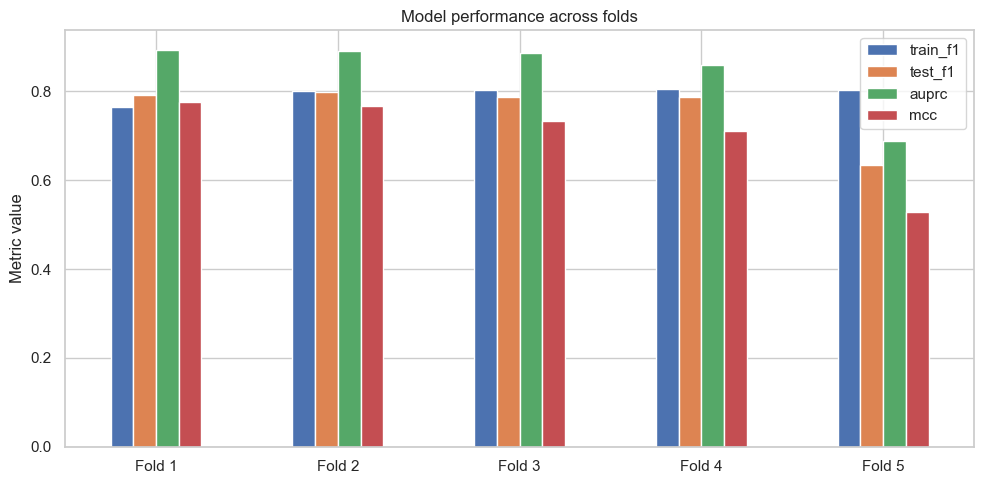

In [19]:
metrics_cols = ["train_f1", "test_f1", "auprc", "mcc"]

results_df[metrics_cols].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Model performance across folds")
plt.ylabel("Metric value")
plt.xticks(
    range(len(results_df)),
    [f"Fold {i}" for i in results_df["fold"]],
    rotation=0
)
plt.tight_layout()
plt.show()


# Confusion Matrix explanation

Confusion matrix shows the number of correct and incorrect predictions.

TP (True Positive) – model correctly predicts alarm.

TN (True Negative) – model correctly predicts no alarm.

FP (False Positive) – model predicts alarm but there is none.

FN (False Negative) – model misses an alarm.

These values help understand what type of mistakes the model makes.

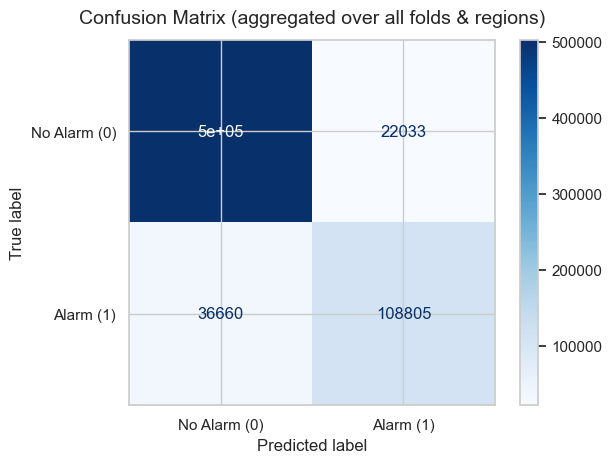

In [20]:
disp = ConfusionMatrixDisplay(
    cm,
    display_labels=["No Alarm (0)", "Alarm (1)"]
)
disp.plot(cmap="Blues")
plt.title(
    "Confusion Matrix (aggregated over all folds & regions)",
    fontsize=14, pad=12
)
plt.tight_layout()
plt.show()


# Top 20 features and weights

In [21]:
feature_names = num_cols + cat_cols

coefficients = model.named_steps["regressor"].coef_

coef_df = pd.DataFrame({
    "feature": feature_names,
    "weight":  coefficients
})
coef_df["abs_weight"] = coef_df["weight"].abs()

top20 = coef_df.sort_values("abs_weight", ascending=False).head(20)
top20


,feature,weight,abs_weight
25,nlp_повітряна_тривога,0.235343,0.235343
24,nlp_повітряна,-0.161202,0.161202
74,alarm_status_1h_ago,0.105457,0.105457
12,messages_count,0.089948,0.089948
17,nlp_відбій_тривоги,0.071147,0.071147
21,nlp_нікополь,-0.053371,0.053371
29,msg_count_last_3h,-0.052785,0.052785
22,nlp_нікополь_нікопольська,0.047555,0.047555
18,nlp_дніпропетровська,-0.030415,0.030415
75,alarm_status_2h_ago,-0.027100,0.027100


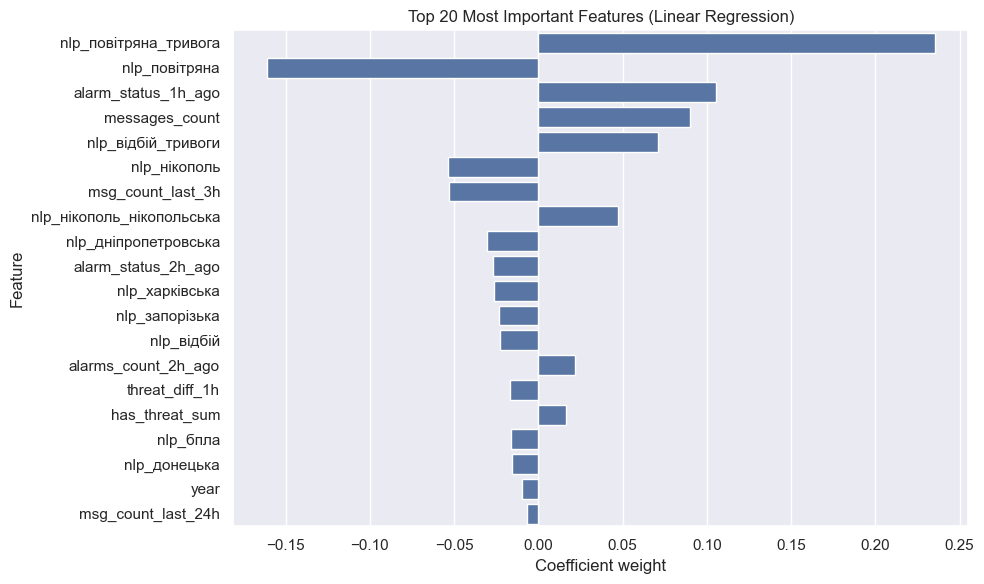

In [22]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top20,
    x="weight",
    y="feature"
)

plt.title("Top 20 Most Important Features (Linear Regression)")
plt.xlabel("Coefficient weight")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()
